In [2]:
import numpy as np                              
import pandas as pd
import re, html, unicodedata      

from scipy import sparse as sp      
from scipy.spatial.distance import cdist

from sklearn.feature_extraction.text import TfidfVectorizer  
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics

import missingno as msno
import matplotlib.pyplot as plt

# Reading in the relevant datasets

In [4]:
books_data = pd.read_csv('data/Books.csv', low_memory=False)
ratings_data = pd.read_csv('data/Ratings.csv')

In [5]:
books_data.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [6]:
ratings_data.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


# Data Exploration

In [8]:
print(f'Dimensions Books.csv : {books_data.shape}')
print(f'Dimensions Ratings.csv : {ratings_data.shape}')

Dimensions Books.csv : (271360, 8)
Dimensions Ratings.csv : (1149780, 3)


In [9]:
books_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [10]:
books_data.describe()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
count,271360,271360,271358,271360,271358,271360,271360,271357
unique,271360,242135,102022,118,16807,271044,271044,271041
top,0195153448,Selected Poems,Agatha Christie,2002,Harlequin,http://images.amazon.com/images/P/185326119X.0...,http://images.amazon.com/images/P/185326119X.0...,http://images.amazon.com/images/P/225307649X.0...
freq,1,27,632,17627,7535,2,2,2


In [11]:
ratings_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [12]:
ratings_data.describe()

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


# Data Cleaning

Let's first clean the **books_data**, and later, move to **ratings_data**

### Cleaning the books data: books_data

In [14]:
books_data.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [15]:
# Complete Rows
books_data.duplicated().sum()

0

In [16]:
# By ISBN
books_data.duplicated(['ISBN']).sum()

0

In [17]:
# Removing the columns that do not have any role to play in Content based filtering
dfb0 = books_data[['ISBN','Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']]
dfb0.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
dtype: int64


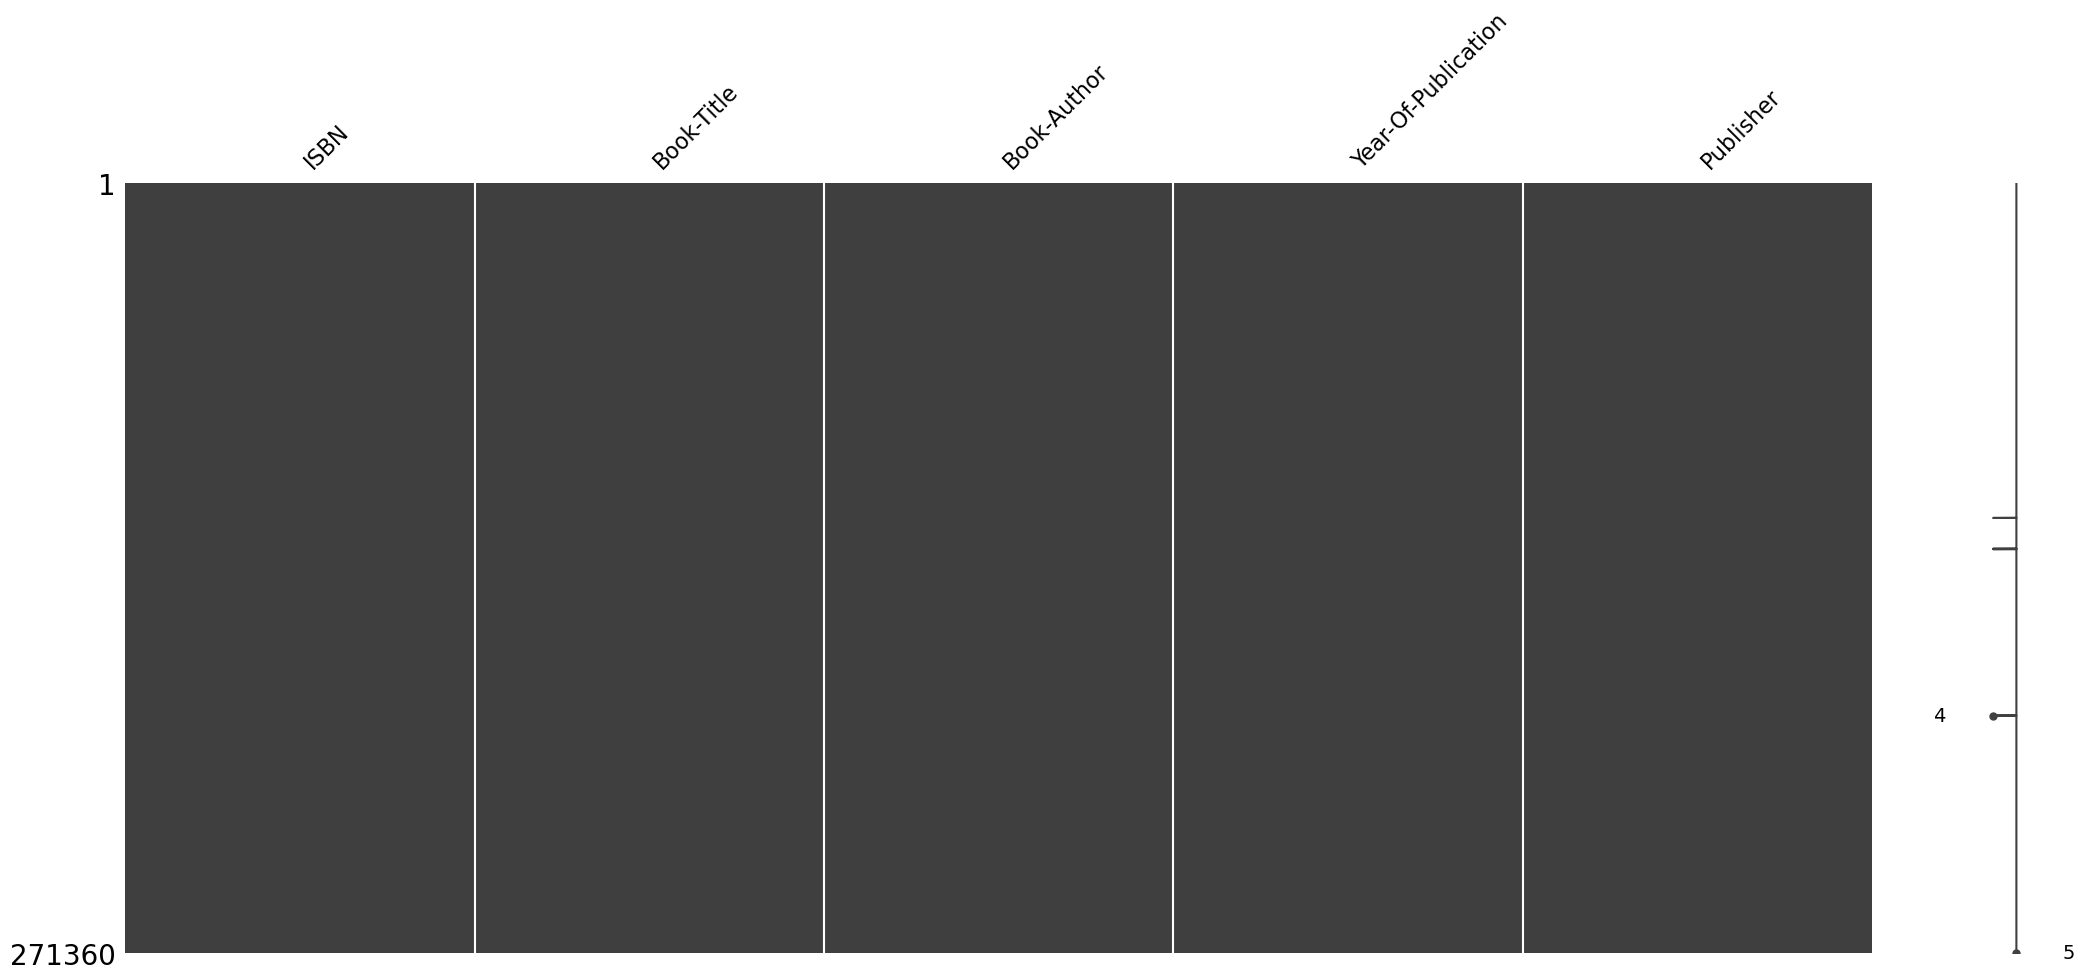

In [18]:
# Checking Missing values
print(dfb0.isnull().sum())

# Visualizing
msno.matrix(dfb0)
plt.show()

In [19]:
# Checking which rows contain missing values
dfb0[dfb0.isnull().any(axis=1)]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing


- Lets remove these rows safely.

In [21]:
print(f"Before removing rows with any NaNs: {dfb0.shape[0]}")

# Removing
dfb1 = dfb0.copy()
dfb1 = dfb1.dropna()
print(f"After removing rows with any NaNs: {dfb1.shape[0]}")


Before removing rows with any NaNs: 271360
After removing rows with any NaNs: 271356


In [22]:
# Convert Year-Of-Publication column to numeric datatype

# dfb0['year_of_publication'] = dfb0['Year-Of-Publication'].astype(float)

# Hits an error due to the presence of literal strings in the column

In [23]:
# Peeking into the bad rows.
dfb1[~dfb1['Year-Of-Publication'].astype(str).str.fullmatch(r'\d{1,4}')]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...


- Seems like `Book-Author` and `Year-Of-Publication` have replaced each other. Lets flip these back to their places.
- Alternatively, these rows can be removed from the dataframe as well.

In [25]:
dfb2 = dfb1[dfb1['Year-Of-Publication'].astype(str).str.fullmatch(r'\d{1,4}')]
dfb2.shape

(271353, 5)

In [26]:
# Further checking into it for whitespaces and doing the conversion
dfb2 = dfb2.copy()
dfb2['year_of_publication'] = dfb2['Year-Of-Publication'].str.strip().astype(float)

In [27]:
dfb2 = dfb2.drop('Year-Of-Publication', axis=1)
dfb2.head()

,ISBN,Book-Title,Book-Author,Publisher,year_of_publication
0,0195153448,Classical Mythology,Mark P. O. Morford,Oxford University Press,2002.0
1,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001.0
2,0060973129,Decision in Normandy,Carlo D'Este,HarperPerennial,1991.0
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,1999.0
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company,1999.0


In [28]:
# Changing column names to snake_case
dfb2 = dfb2.rename(columns = {'ISBN': 'isbn', 
                     'Book-Title': 'book_title',
                     'Book-Author': 'book_author', 
                     'Publisher': 'publisher'
                    }
                   )

- The range of the years in `year_of_publication` is not valid, with years like 0.00, or 2050. Lets filter it for a certain window, e.g: from 1500 to 2025.
- Clean the text from HTML tags, and standardize it.
- Standardize the author names
- Make an extra feature that bins years into decades
- Concatenate author and book's name.

In [30]:
def legit_years(df, col, min_year, max_year):
    """
    Excludes the rows that do not fall in the given range of years.
    """
    df = df[(df['year_of_publication'] > 1500) & (df['year_of_publication'] < 2025)]
    return df
    
def clean_text(s):
    """ 
    Unescape HTML, normalize unicode, lowercase, trim and collapse spaces.
    """
    if s is None or (isinstance(s, float) and np.isnan(s)): # guard None/NaN → empty
        s = ''
    s = html.unescape(s) # "&amp;" → "&"
    s = unicodedata.normalize('NFKC', s) # normalize unicode (accents, widths)
    s = s.strip().lower() # trim and lowercase
    s = re.sub(r"\s+", " ", s) # collapse repeated spaces
    return s

def normalize_author(s):
    s = clean_text(s) # basic cleaning (HTML unescape, NFKC, lowercase, trim)
    s = re.sub(r"\b([a-z])\.\s*", r"\1", s) # "j. k." to "jk"  (clean_text lowercases, so [a-z] is fine)
    s = s.replace(",", " ") # "rowling, j k" to "rowling  j k"
    s = re.sub(r"\s+", " ", s) # collapse multiple spaces
    return s

def decade_token(year):
    """
    Maps years to decades as an engineered feature.
    """
    if pd.isna(year): # missing year
        return "unknown_decade" 
    try:
        year_val = int(year)
        if 1500 < year_val < 2025:
            decade = year_val // 100
            decade_val = 'decade_'+ str((year_val // 10) * 10) # 1999 to "decade_1990"
            return decade_val
    except Exception:
        pass
    return "unknown_decade"

def canonical_key(title, author):
    """
    Used to dedupe editions: same (normalized title|author) treated as one.
    """
    clean_title = clean_text(title)
    normalized_author = normalize_author(author)
    return_str = str(clean_title) + '|' + str(normalized_author)
    return return_str


# Prepare/augment the books table for vectorization
def prepare_books(books_df):
    """Return a cleaned copy with helper columns we’ll vectorize."""
    df = books_df.copy() # don’t mutate original
    df = legit_years(df, 'year_of_publication', 1500, 2025) # Discard the rows with publication years out of the range.
    df['isbn'] = df['isbn'].str.strip()
    # fill missing text columns with empty strings
    for col in ["book_title", "book_author", "publisher"]:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")
        df[col] = df[col].fillna("")
    # create normalized helper columns
    df["_title_norm"] = df["book_title"].map(clean_text) # clean title
    df["_author_norm"] = df["book_author"].map(normalize_author) # normalize author
    df["_publisher_norm"] = df["publisher"].map(clean_text) # clean publisher
    df["_decade_tok"] = df["year_of_publication"].map(decade_token) # turn year → decade token
    return df 

Cleaning steps are being done for books_data (alias dfb2)

In [32]:
df_books_prepared = prepare_books(dfb2)
df_books_prepared.head()

,isbn,book_title,book_author,publisher,year_of_publication,_title_norm,_author_norm,_publisher_norm,_decade_tok
0,0195153448,Classical Mythology,Mark P. O. Morford,Oxford University Press,2002.0,classical mythology,mark pomorford,oxford university press,decade_2000
1,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001.0,clara callan,richard bruce wright,harperflamingo canada,decade_2000
2,0060973129,Decision in Normandy,Carlo D'Este,HarperPerennial,1991.0,decision in normandy,carlo d'este,harperperennial,decade_1990
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,1999.0,flu: the story of the great influenza pandemic...,gina bari kolata,farrar straus giroux,decade_1990
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company,1999.0,the mummies of urumchi,ejwbarber,w. w. norton & company,decade_1990


In [33]:
# Recheck the duplicates as we just cleaned the white spaces
df_books_prepared[df_books_prepared.duplicated(keep=False)]

,isbn,book_title,book_author,publisher,year_of_publication,_title_norm,_author_norm,_publisher_norm,_decade_tok
111653,0486404242,War in Kind: And Other Poems (Dover Thrift Edi...,Stephen Crane,Dover Publications,1998.0,war in kind: and other poems (dover thrift edi...,stephen crane,dover publications,decade_1990
111808,0486404242,War in Kind: And Other Poems (Dover Thrift Edi...,Stephen Crane,Dover Publications,1998.0,war in kind: and other poems (dover thrift edi...,stephen crane,dover publications,decade_1990


- Found 1 duplicate row (after cleaning whitespaces)

Lets remove one of the rows

In [35]:
df_books_prepared = df_books_prepared.drop_duplicates()
df_books_prepared[df_books_prepared.duplicated(keep=False)]

,isbn,book_title,book_author,publisher,year_of_publication,_title_norm,_author_norm,_publisher_norm,_decade_tok


- Duplicates cleaned

### Cleaning the ratings data: ratings_data

In [38]:
ratings_data.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [39]:
# Checking duplicate rows:
ratings_data.duplicated().sum()

0

In [40]:
# Checking the null values
ratings_data.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [41]:
ratings_data

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


In [42]:
ratings_data.describe()

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


In [43]:
dfr1 = ratings_data.rename(columns={'User-ID':'user', 'Book-Rating':'rating', 'ISBN':'isbn'})
dfr1.head()

,user,isbn,rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [44]:
# To be on the safe side, let's trim any possible whitespaces from the string columns
dfr1['isbn'] = dfr1['isbn'].str.strip()

- So far, it doesn't appear that **rating_data** requires any further cleaning steps

In [46]:
dfr1.shape

(1149780, 3)

In [47]:
# The version of rating_data I'll be using:
df_ratings = dfr1.copy()
df_ratings.head()

,user,isbn,rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


# Data Analysis

To understand how both tables, `df_ratings` and `df_books_prepared`, relate to each other, let's do dig into some data analysis

In [49]:
isbn_books = df_books_prepared['isbn'].unique().tolist()
isbn_ratings = df_ratings['isbn'].unique().tolist()

print(f"Unique ISBNs in books table: {len(isbn_books)}")
print(f"Unique ISBNs in ratings table: {len(isbn_ratings)}")

Unique ISBNs in books table: 266720
Unique ISBNs in ratings table: 340553


In [50]:
set_isbn_books = set(isbn_books)
set_isbn_ratings = set(isbn_ratings)

In [51]:
isbns_in_books_not_in_ratings = set_isbn_ratings - set_isbn_books
isbns_in_ratings_not_in_books = set_isbn_books - set_isbn_ratings

print(f"Number of ISBNs present in ratings data BUT NOT in books data : {len(isbns_in_books_not_in_ratings)}")
print(f"Number of ISBNs present in books data BUT NOT in ratings data : {len(isbns_in_ratings_not_in_books)}")

Number of ISBNs present in ratings data BUT NOT in books data : 75020
Number of ISBNs present in books data BUT NOT in ratings data : 1187


**Important:**

While looking at the ISBNs that are in the rating data but not in the books data, it can be said that some ISBN entries are corrupt. For an instance, some of the ISBNs starts with the string *ISBN*, which are definitely the typos. Also, after some R&D, it can be concluded that:
- An ISBN is either a 10-digit or a 13-digit string.
- The only letter allowed in an ISBN is the capital letter "X"
- ISBNs were introduced in 1970. Earlier than this, there were no ISBNs

In [53]:
# Some manual inspection
# isbns_in_ratings_not_in_books

In [54]:
df_ratings['isbn'].str.len().value_counts()

isbn
10    1139377
9        5140
11       2136
13       1740
12        700
8         677
14         10
Name: count, dtype: int64

- It can be seen that `df_ratings` has a lot of potentially corrupt ISBN entries.

In [56]:
df_ratings[df_ratings['isbn'].str.startswith('ISBN')]

,user,isbn,rating
58910,11676,ISBN067172365,5
58911,11676,ISBN068481039,10
65523,13403,ISBN:08112003,4
66951,13711,ISBN:08820775,10
88669,19592,ISBN073941625,6
...,...,...,...
1142377,274383,ISBN082450431,10
1142378,274383,ISBN082640047,10
1142379,274383,ISBN088344090,10
1142380,274383,ISBN088730431,10


- There are also some rows where ISBN starts with the text *ISBN*. There is a high probability that these are typos.

Lets first look into possibilities where a valid 10-character long ISBN is corrupted by having a prefix *ISBN* text and fix these.

In [58]:
df_ratings[(df_ratings['isbn'].str.startswith('ISBN')) & (df_ratings['isbn'].str.len() == 14)]

,user,isbn,rating


- There are no such entries! 

Let's remove this invalid prefix from all the ISBN entries

In [63]:
df_ratings[df_ratings['isbn'].str.startswith('ISBN')]

,user,isbn,rating
58910,11676,ISBN067172365,5
58911,11676,ISBN068481039,10
65523,13403,ISBN:08112003,4
66951,13711,ISBN:08820775,10
88669,19592,ISBN073941625,6
...,...,...,...
1142377,274383,ISBN082450431,10
1142378,274383,ISBN082640047,10
1142379,274383,ISBN088344090,10
1142380,274383,ISBN088730431,10


In [65]:
df_ratings["isbn"] = df_ratings["isbn"].str.replace(r"^ISBN[:\s]*", "", regex=True)
df_ratings['isbn'].str.len().value_counts()

isbn
10    1139377
9        5196
11       2136
13       1675
12        700
8         686
14         10
Name: count, dtype: int64

**Important:**

- It is also possible that the books published before the 1970 followed a different system from ISBN, and the column's name `ISBN` is a misnomer. If I remove all those books that do not follow a legit ISBN, I will be left with the books that were published post-1970. And this can deplete us with quality data. 

- To decide on this, let's test books_data with a similar test.

In [67]:
df_books_prepared.shape

(266720, 9)

In [68]:
df_books_prepared['isbn'].str.len().value_counts()

isbn
10    266717
13         3
Name: count, dtype: int64

In [69]:
(df_books_prepared[df_books_prepared['year_of_publication'] < 1970]).shape

(2687, 9)

- There are some 2687 books out of 266720 books that have a publication date prior to 1970. This is nearly 1% of entire data.

Therefore, let's prefer standardizing the data rather than keeping these rows.

In [71]:
df_books_prepared = df_books_prepared[(df_books_prepared['isbn'].str.fullmatch(r'^[0-9xX\s-]+$')) & (df_books_prepared['year_of_publication'] >= 1970)]

In [72]:
df_books_prepared.shape

(263975, 9)

In [245]:
# Lets save this version of df_books_prepared.
# df_books_prepared.to_csv('data/df_books_prepared.csv', index=False)

In [210]:
df_ratings.head()

,user,isbn,rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [212]:
df_ratings.shape

(1149780, 3)

Looking into the Ratings data, there are some ISBN entries that do not exist in Books data. Lets look into those.
- Around 6% data in the `df_ratings` that do not have **ISBNs** in common with `df_books_prepared` table. 

In [221]:
df_ratings.merge?

Signature:
df_ratings.merge(
    right: 'DataFrame | Series',
    how: 'MergeHow' = 'inner',
    on: 'IndexLabel | None' = None,
    left_on: 'IndexLabel | None' = None,
    right_on: 'IndexLabel | None' = None,
    left_index: 'bool' = False,
    right_index: 'bool' = False,
    sort: 'bool' = False,
    suffixes: 'Suffixes' = ('_x', '_y'),
    copy: 'bool | None' = None,
    indicator: 'str | bool' = False,
    validate: 'MergeValidate | None' = None,
) -> 'DataFrame'
Docstring:
Merge DataFrame or named Series objects with a database-style join.

A named Series object is treated as a DataFrame with a single named column.

The join is done on columns or indexes. If joining columns on
columns, the DataFrame indexes *will be ignored*. Otherwise if joining indexes
on indexes or indexes on a column or columns, the index will be passed on.
When performing a cross merge, no column specifications to merge on are
allowed.

.. warning::

    If both key columns contain rows where the key is a 

In [223]:
# Merging on ISBNs
df_ratings_prepared = df_ratings.merge(df_books_prepared, 
                                         how = 'inner', 
                                         on = 'isbn')
# Only keeping the columns that are part of the ratings's data.
df_ratings_prepared = df_ratings_prepared[['user', 'isbn', 'rating']]

In [229]:
# Lets save this version of df_ratings.
# df_ratings_prepared.to_csv('data/df_ratings_prepared.csv', index = False)

# Content Based Recommendation System

---

In [84]:
# CFG = {
#     "title": {"ngram_range": (1, 2), "min_df": 5, "max_df": 0.8, "weight": 1.5}, # word unigrams+bigrams
#     "author": {"char_ngram_range": (3, 5), "min_df": 2, "weight": 2.0}, # char n-grams (robust to variants)
#     "publisher": {"ngram_range": (1, 1), "min_df": 5, "max_df": 0.9, "weight": 0.5}, # weaker signal
#     "decade": {"weight": 0.25}, # tiny categorical feature
#     "use_svd": False, # set True to enable TF-IDF -> SVD to 256 dims (faster, smaller)
#     "svd_dim": 256, # SVD output size
#     "metric": "cosine", # distance metric for neighbors (similarity = 1 - distance)
#     "n_neighbors_fit": 200 # how many neighbors to search for by default (we’ll oversample then filter)
# }

In [86]:
# # ============================
# # 1) Imports and basic config
# # ============================
# import re, html, unicodedata                    # stdlib: regex, HTML unescape, unicode normalization
# import numpy as np                              # arrays and math
# import pandas as pd                             # dataframes
# from scipy import sparse as sp                  # sparse matrices
# from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF vectorizers
# from sklearn.preprocessing import normalize     # L2-normalization for rows
# from sklearn.decomposition import TruncatedSVD  # optional: reduce dims (LSA)
# from sklearn.neighbors import NearestNeighbors  # fast KNN over vectors

# # Simple config dictionary you can tweak later
# CFG = {
#     "title":     {"ngram_range": (1, 2), "min_df": 5, "max_df": 0.8, "weight": 1.5},  # word unigrams+bigrams
#     "author":    {"char_ngram_range": (3, 5), "min_df": 2, "weight": 2.0},            # char n-grams (robust to variants)
#     "publisher": {"ngram_range": (1, 1), "min_df": 5, "max_df": 0.9, "weight": 0.5},  # weaker signal
#     "decade":    {"weight": 0.25},                                                    # tiny categorical feature
#     "use_svd": False,          # set True to enable TF-IDF -> SVD to 256 dims (faster, smaller)
#     "svd_dim": 256,            # SVD output size
#     "metric": "cosine",        # distance metric for neighbors (similarity = 1 - distance)
#     "n_neighbors_fit": 200     # how many neighbors to search for by default (we’ll oversample then filter)
# }

# # ====================================
# # 2) Tiny text helpers (clean/normalize)
# # ====================================

# def clean_text(s):
#     """Unescape HTML, normalize unicode, lowercase, trim and collapse spaces."""
#     s = "" if s is None or (isinstance(s, float) and np.isnan(s)) else str(s)     # guard None/NaN → empty
#     s = html.unescape(s)                                                           # "&amp;" → "&"
#     s = unicodedata.normalize("NFKC", s)                                           # normalize unicode (accents, widths)
#     s = s.strip().lower()                                                          # trim and lowercase
#     s = re.sub(r"\s+", " ", s)                                                     # collapse repeated spaces
#     return s

# def normalize_author(s):
#     """Normalize author strings (remove dots in initials, commas → spaces, collapse)."""
#     s = clean_text(s)                                                              # basic cleaning
#     s = re.sub(r"\b([a-z])\.\s*", r"\1", s)                                        # "j. k." → "jk"
#     s = s.replace(",", " ")                                                        # "rowling, j k" → "rowling  j k"
#     s = re.sub(r"\s+", " ", s)                                                     # collapse spaces again
#     return s

# def decade_token(year):
#     """Map numeric year to 'decade_1990s' etc.; unknown → 'decade_unknown'."""
#     if pd.isna(year):                                                               # missing year
#         return "decade_unknown"
#     try:
#         y = int(year)                                                               # cast 2002.0 → 2002
#         if 1400 <= y <= 2025:                                                       # sanity range (tune as you like)
#             return f"decade_{(y // 10) * 10}s"                                      # 1999 → "decade_1990s"
#     except Exception:
#         pass
#     return "decade_unknown"                                                         # fallback token

# def canonical_key(title, author):
#     """Used to dedupe editions: same (normalized title|author) treated as one."""
#     return f"{clean_text(title)}|{normalize_author(author)}"


# # ===========================================================
# # 3) Prepare/augment the books table for vectorization
# # ===========================================================

# def prepare_books(books_df):
#     """Return a cleaned copy with helper columns we’ll vectorize."""
#     df = books_df.copy()                                                             # don’t mutate original
#     # fill missing text columns with empty strings
#     for col in ["Book-Title", "Book-Author", "Publisher"]:
#         if col not in df.columns:
#             raise ValueError(f"Missing column: {col}")
#         df[col] = df[col].fillna("")
#     # create normalized helper columns
#     df["_title_norm"]     = df["Book-Title"].map(clean_text)                         # clean title
#     df["_author_norm"]    = df["Book-Author"].map(normalize_author)                  # normalize author
#     df["_publisher_norm"] = df["Publisher"].map(clean_text)                          # clean publisher
#     df["_decade_tok"]     = df["year_of_publication"].map(decade_token)              # turn year → decade token
#     return df                                                                         # ready for TF-IDF


# # ==========================================================================
# # 4) Build field-weighted TF-IDF matrix (optionally reduce with SVD/LSA)
# # ==========================================================================

# def build_item_matrix(prepared_books, cfg=CFG):
#     """Return the vector matrix X (sparse or dense), vectorizers, and lookups."""
#     df = prepared_books                                                               # shorter alias

#     # ---------- Title vectorizer (word n-grams) ----------
#     vec_title = TfidfVectorizer(
#         analyzer="word",                                                              # split on words
#         ngram_range=cfg["title"]["ngram_range"],                                      # (1,2) → unigrams+bigrams
#         min_df=cfg["title"]["min_df"],                                                # ignore very rare tokens
#         max_df=cfg["title"]["max_df"],                                                # ignore too common tokens
#         sublinear_tf=True,                                                            # log-scaling of term frequency
#         norm="l2"                                                                     # L2-normalize each row
#     )
#     Xt = vec_title.fit_transform(df["_title_norm"])                                   # fit vocab, build matrix

#     # ---------- Author vectorizer (character n-grams) ----------
#     vec_author = TfidfVectorizer(
#         analyzer="char_wb",                                                           # character n-grams within word boundaries
#         ngram_range=cfg["author"]["char_ngram_range"],                                # (3,5) handles spelling variants
#         min_df=cfg["author"]["min_df"],                                               # ignore ultra-rare names
#         norm="l2"                                                                     # L2-normalize each row
#     )
#     Xa = vec_author.fit_transform(df["_author_norm"])                                 # author char-ngram matrix

#     # ---------- Publisher vectorizer (word unigrams) ----------
#     vec_publisher = TfidfVectorizer(
#         analyzer="word",                                                              # word tokens
#         ngram_range=cfg["publisher"]["ngram_range"],                                  # (1,1) → unigrams
#         min_df=cfg["publisher"]["min_df"],                                            # ignore rare publishers
#         max_df=cfg["publisher"]["max_df"],                                            # ignore too common publishers
#         sublinear_tf=True,                                                            # log-scaling
#         norm="l2"                                                                     # L2-normalize
#     )
#     Xp = vec_publisher.fit_transform(df["_publisher_norm"])                           # publisher matrix

#     # ---------- Decade vectorizer (tiny vocab) ----------
#     vec_decade = TfidfVectorizer(
#         analyzer="word", ngram_range=(1, 1), min_df=1, norm="l2"                      # simple one-hot via TF-IDF
#     )
#     Xd = vec_decade.fit_transform(df["_decade_tok"])                                  # decade matrix

#     # ---------- Apply field weights ----------
#     Xt = Xt * cfg["title"]["weight"]                                                  # upweight title signal
#     Xa = Xa * cfg["author"]["weight"]                                                 # upweight author loyalty
#     Xp = Xp * cfg["publisher"]["weight"]                                              # downweight publisher
#     Xd = Xd * cfg["decade"]["weight"]                                                 # tiny weight for decade

#     # ---------- Combine all fields into one matrix ----------
#     X_sparse = sp.hstack([Xt, Xa, Xp, Xd], format="csr")                              # horizontal stack (same rows)
#     X_sparse = normalize(X_sparse, norm="l2", axis=1, copy=False)                     # row-normalize for cosine

#     # ---------- Optional dimensionality reduction (LSA) ----------
#     if cfg["use_svd"]:                                                                # toggleable for speed/size
#         svd = TruncatedSVD(n_components=cfg["svd_dim"], random_state=42)              # set output dimension
#         X_dense = svd.fit_transform(X_sparse)                                         # project to dense vectors
#         X = normalize(X_dense, norm="l2", axis=1)                                     # row-normalize again
#     else:
#         svd = None                                                                    # no SVD used
#         X = X_sparse                                                                  # keep sparse matrix

#     # ---------- Nearest neighbors index (for fast similarity) ----------
#     nn = NearestNeighbors(metric=cfg["metric"], algorithm="brute")                    # cosine distance
#     nn.fit(X)                                                                         # index the vectors

#     # ---------- Build lookups we’ll need later ----------
#     idx_to_isbn = list(df["ISBN"].values)                                             # row index → ISBN
#     isbn_to_idx = {isbn: i for i, isbn in enumerate(idx_to_isbn)}                     # ISBN → row index
#     canonical_list = [canonical_key(t, a) for t, a in zip(df["Book-Title"], df["Book-Author"])]  # for dedupe
#     author_norm_list = list(df["_author_norm"].values)                                # normalized authors for caps

#     # ---------- Return everything in a simple state dict ----------
#     state = {
#         "X": X,                             # final item vectors (sparse or dense)
#         "X_sparse": X_sparse,               # always keep sparse around (for user vector math)
#         "svd": svd,                         # None if not used
#         "nn": nn,                           # fitted neighbor index
#         "vec_title": vec_title,             # fitted vectorizers (handy for debugging/explanations)
#         "vec_author": vec_author,
#         "vec_publisher": vec_publisher,
#         "vec_decade": vec_decade,
#         "books": df[["ISBN","Book-Title","Book-Author","Publisher","year_of_publication"]].reset_index(drop=True),
#         "isbn_to_idx": isbn_to_idx,
#         "idx_to_isbn": idx_to_isbn,
#         "canonical": canonical_list,
#         "author_norm": author_norm_list,
#         "cfg": cfg
#     }
#     return state


# # ==================================================================================
# # 5) Item → item “similar books” (with simple dedupe and same-author cap)
# # ==================================================================================

# def similar_books(isbn, state, k=20, max_same_author_ratio=0.6):
#     """Return a DataFrame of k similar books to the given ISBN."""
#     if isbn not in state["isbn_to_idx"]:                                              # guard unknown ISBNs
#         raise KeyError(f"ISBN not found: {isbn}")
#     i = state["isbn_to_idx"][isbn]                                                    # row index of the query book
#     X = state["X"]                                                                     # item matrix
#     nn = state["nn"]                                                                   # neighbor index
#     n_total = X.shape[0]                                                               # number of items

#     # retrieve neighbors (oversample by +50 so filtering doesn’t starve results)
#     distances, indices = nn.kneighbors(X[i], n_neighbors=min(k + 50, n_total))        # nearest by cosine distance
#     sims = 1.0 - distances[0]                                                          # convert distance → similarity
#     cand_idxs = indices[0].tolist()                                                    # list of candidate row indices

#     # filtering: remove self, collapse editions, cap same-author dominance
#     kept = []                                                                          # will store (idx, sim)
#     seen_canon = set()                                                                 # track canonical keys to dedupe
#     author_counts = {}                                                                 # count how many per author

#     for idx, sim in zip(cand_idxs, sims):
#         if idx == i:                                                                   # skip itself
#             continue
#         canon_i = state["canonical"][i]                                               # canonical of the query
#         canon_j = state["canonical"][idx]                                             # canonical of the candidate
#         if canon_j == canon_i:                                                         # skip same (edition) as query
#             continue
#         if canon_j in seen_canon:                                                      # skip duplicates of same work
#             continue

#         auth_j = state["author_norm"][idx]                                            # normalized author of candidate
#         author_counts.setdefault(auth_j, 0)                                           # initialize if unseen
#         # check if adding this would break the cap (e.g., >60% same author among kept)
#         if len(kept) > 0 and (author_counts[auth_j] + 1) / (len(kept) + 1) > max_same_author_ratio:
#             continue

#         kept.append((idx, float(sim)))                                                # accept candidate
#         seen_canon.add(canon_j)                                                       # remember its canonical key
#         author_counts[auth_j] += 1                                                    # bump author count

#         if len(kept) >= k:                                                            # stop when we have k items
#             break

#     # build a small, friendly DataFrame to return
#     rows = []
#     for idx, sim in kept:
#         item = state["books"].iloc[idx]
#         rows.append({
#             "ISBN": item["ISBN"],
#             "Book-Title": item["Book-Title"],
#             "Book-Author": item["Book-Author"],
#             "Publisher": item["Publisher"],
#             "year_of_publication": item["year_of_publication"],
#             "similarity": sim
#         })
#     return pd.DataFrame(rows)


# # ==================================================================================
# # 6) User-level personalized recs by averaging liked item vectors
# # ==================================================================================

# def recommend_for_user(user_id, ratings_df, state, k=20, positive_threshold=7,
#                        weight_by_rating=True, exclude_seen=True, max_same_author_ratio=0.6):
#     """Return k personalized recommendations for a user using their positive ratings."""
#     # pull this user's ratings
#     r = ratings_df.loc[ratings_df["User-ID"] == user_id, ["ISBN", "Book-Rating"]]     # slice only needed cols
#     if r.empty:                                                                        # guard no data
#         raise ValueError(f"No ratings for user {user_id}")

#     # define positives (e.g., rating ≥ 7). if none, fallback to “all rated” to avoid empty set
#     pos = r[r["Book-Rating"] >= positive_threshold]
#     if pos.empty:
#         pos = r.copy()

#     # map positive ISBNs to row indices in our item matrix
#     idxs = []
#     weights = []
#     for isbn, rating in zip(pos["ISBN"].values, pos["Book-Rating"].values):
#         if isbn in state["isbn_to_idx"]:
#             idxs.append(state["isbn_to_idx"][isbn])
#             weights.append(float(rating))
#     if not idxs:                                                                       # guard no overlap with catalog
#         raise ValueError("User has no positive books present in the indexed catalog.")

#     # compute weights (optionally mean-centered ratings to reduce popularity bias)
#     if weight_by_rating:
#         w = np.asarray(weights, dtype=np.float32)
#         w = w - w.mean()                                                               # center; may become all zeros
#         if np.allclose(w, 0):                                                          # if all equal, fallback to ones
#             w = np.ones_like(w)
#     else:
#         w = np.ones(len(idxs), dtype=np.float32)

#     # build a single user vector as a weighted average of liked item vectors
#     X = state["X"]                                                                      # item matrix (sparse or dense)
#     if sp.issparse(X):                                                                  # if sparse, use sparse ops
#         # take rows, multiply by weights, sum rows → 1 x D vector
#         user_vec = X[idxs].multiply(w[:, None]).sum(axis=0)                             # 1xD (scipy sparse matrix)
#         user_vec = np.asarray(user_vec)                                                 # convert to dense ndarray
#     else:
#         user_vec = (X[idxs] * w[:, None]).sum(axis=0, keepdims=True)                    # 1xD dense

#     # L2-normalize the user vector so cosine works as dot product
#     norm = np.linalg.norm(user_vec) + 1e-12                                             # avoid divide-by-zero
#     user_vec = user_vec / norm                                                          # normalized 1xD

#     # find nearest items to this user vector (oversample for filtering)
#     nn = state["nn"]
#     n_total = X.shape[0]
#     distances, indices = nn.kneighbors(user_vec, n_neighbors=min(k + 200, n_total))     # more candidates
#     sims = 1.0 - distances[0]
#     cand_idxs = indices[0].tolist()

#     # option: exclude items the user already rated
#     seen_isbns = set(r["ISBN"].values) if exclude_seen else set()

#     # apply same dedupe + same-author cap as above
#     kept, seen_canon, author_counts = [], set(), {}
#     for idx, sim in zip(cand_idxs, sims):
#         isbn_j = state["idx_to_isbn"][idx]                                             # candidate ISBN (for seen check)
#         if isbn_j in seen_isbns:                                                       # skip already seen
#             continue
#         canon_j = state["canonical"][idx]                                              # canonical key of candidate
#         if canon_j in seen_canon:                                                      # skip duplicate editions
#             continue

#         auth_j = state["author_norm"][idx]                                            # normalized author of candidate
#         author_counts.setdefault(auth_j, 0)
#         if len(kept) > 0 and (author_counts[auth_j] + 1) / (len(kept) + 1) > max_same_author_ratio:
#             continue

#         kept.append((idx, float(sim)))                                                # accept candidate
#         seen_canon.add(canon_j)
#         author_counts[auth_j] += 1

#         if len(kept) >= k:
#             break

#     # return as a small DataFrame
#     rows = []
#     for idx, score in kept:
#         item = state["books"].iloc[idx]
#         rows.append({
#             "ISBN": item["ISBN"],
#             "Book-Title": item["Book-Title"],
#             "Book-Author": item["Book-Author"],
#             "Publisher": item["Publisher"],
#             "year_of_publication": item["year_of_publication"],
#             "score": score
#         })
#     return pd.DataFrame(rows)


# # ======================================
# # 7) One-shot build function + examples
# # ======================================

# def build_content_recommender(books_df, cfg=CFG):
#     """Convenience: prepare books and build the matrix + index in one call."""
#     prepared = prepare_books(books_df)                                                # add helper text columns
#     state = build_item_matrix(prepared, cfg=cfg)                                      # vectorize and index
#     return state                                                                       # keep this dict around

# # --- Example usage (uncomment to run) ---
# state = build_content_recommender(dfb2, cfg=CFG)                                # build once
# isbn0 = dfb2["ISBN"].iloc[0]                                                    # pick an ISBN
# # print(similar_books(isbn0, state, k=20))                                            # item→item neighbors
# print(recommend_for_user(user_id=276723, ratings_df=ratings_data, state=state, k=20))    # personalized recs


---

### Vectorizers


##### Title (`_title_norm`)

In [90]:
# Create a TF-IDF vectorizer for book titles. Tokenize on words.
vec_title = TfidfVectorizer(
    analyzer = 'word', # Tokenize on words.
    ngram_range = (1, 2), # Use unigrams/bigrams etc.
    min_df = 5, # Drop tokens occurring in fewer than min_df documents
    max_df = 0.8, # Drop tokens appearing in more than this fraction of documents (too common).
    sublinear_tf = True, # Log-scale term counts to dampen raw frequency spikes.
    norm = 'l2' # L2-normalize each row vector (per item) in this block.
)

Xt = vec_title.fit_transform(df_books_prepared['_title_norm'])

##### Author (`_author_norm`)

In [92]:
vec_author = TfidfVectorizer(
    analyzer = 'char_wb', # Character n-grams inside word boundaries
    ngram_range = (3, 5), # (3,5) character n-grams.
    min_df = 2, # Drop super-rare n-grams
    norm = 'l2' # Normalize per row.
)

Xa = vec_author.fit_transform(df_books_prepared['_author_norm'])

##### Publisher (`_publisher_norm`)

In [94]:
vec_publisher  = TfidfVectorizer(
    analyzer = 'word', # Tokenize on words
    ngram_range = (1, 1), # Use unigrams
    min_df = 5, # Drop rare publishers
    max_df = 0.9, # Drop extremely common publishers
    sublinear_tf = True, # Log-scale term counts to dampen raw frequency spikes.
    norm = 'l2' # L2-normalize each row vector (per item) in this block.
    )

Xp = vec_publisher.fit_transform(df_books_prepared['_publisher_norm'])

##### Decade (`_decade_norm`)

In [96]:
vec_decade = TfidfVectorizer(
    analyzer="word", # Simple one-hot via TF-IDF with normalization.
    ngram_range=(1, 1), # Use unigrams
    min_df=1, # Drop rare decades
    norm="l2" # L2 normalization.
)

Xd = vec_decade.fit_transform(df_books_prepared['_decade_tok']) 

#### Applying field weights and combining all fields into a single matrix

In [98]:
weight_dict = {
    'title': 1.5,
    'author': 2.0,
    'publisher': 0.5,
    'decade': 0.25 
              }

Xt = Xt * weight_dict["title"] # upweight title signal by 1.5
Xa = Xa * weight_dict["author"] # upweight author loyalty by 2.0
Xp = Xp * weight_dict["publisher"] # downweight publisher by 0.5
Xd = Xd * weight_dict["decade"] # tiny weight for decade like 0.25

In [99]:
# Horizontal Stack Horizontally stack the four sparse blocks into a single sparse matrix (rows = items; columns = concatenated features). 
# Keep CSR format for efficient row ops.
X_sparse = sp.hstack([Xt, Xa, Xp, Xd], format="csr")

# L2-normalize each row of the combined matrix so cosine similarity = dot product.
X_sparse = normalize(X_sparse, norm="l2", axis=1, copy=False)

In [100]:
want_svd = None

if want_svd != None:
    # set output dimension
    svd = TruncatedSVD(n_components=cfg["svd_dim"], random_state=42) 
    
    # project to dense vectors
    X_dense = svd.fit_transform(X_sparse) 
    
    # row-normalize again
    X = normalize(X_dense, norm="l2", axis=1)
else:
    # Ignore SVD, X is same as X_sparse
    X = X_sparse

### Nearest neighbors index (for fast similarity)

Using the Elbow method to find out the ideal number of clusters to be used

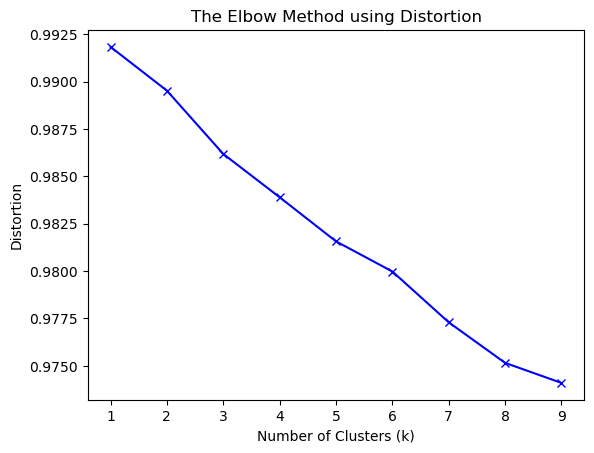

In [103]:
distortions = []
inertias = []
mapping1, mapping2 = {}, {}
K = range(1, 10)

n_samples = X.shape[0]

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X)
    inertia = km.inertia_
    inertias.append(inertia)
    distortion = inertia / n_samples
    distortions.append(distortion)
    mapping1[k] = distortion
    mapping2[k] = inertia

# Visualize
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

- It's not very clear to observe an elbow in the plot of **Elbow Method**, let's move forward with 5 clusters.

In [139]:
nn = NearestNeighbors(n_neighbors=5, 
                      metric='cosine', 
                      algorithm='brute') # cosine distance
nn.fit(X)

NearestNeighbors(algorithm='brute', metric='cosine')

In [143]:
# Gathering row index to isbns
idx_to_isbn = list(df_books_prepared['isbn'].values)

# Gathering isbns to row index
isbn_to_idx = dict()
for i, val in enumerate(idx_to_isbn):
    isbn_to_idx[val] = i

# For Deduplication
canonical_list = []
for t, a in zip(df_books_prepared['book_title'], df_books_prepared['book_author']):
    canonical_list.append(canonical_key(t, a))

# normalized authors for caps
author_norm_list = list(df_books_prepared["_author_norm"].values)

#### Creating a dictionary called `STATE` to hold everything

In [146]:
STATE = {
    "X": X, # final item vectors (sparse or dense)
    "X_sparse": X_sparse, # always keep sparse around (for user vector math)
    "svd": want_svd, # None if not used
    "nn": nn, # fitted neighbor index
    "vec_title": vec_title, # fitted vectorizers (handy for debugging/explanations)
    "vec_author": vec_author,
    "vec_publisher": vec_publisher,
    "vec_decade": vec_decade,
    "books": df_books_prepared[["isbn","book_title","book_author","publisher","year_of_publication"]].reset_index(drop=True),
    "isbn_to_idx": isbn_to_idx,
    "idx_to_isbn": idx_to_isbn,
    "canonical": canonical_list,
    "author_norm": author_norm_list
}

### Finding similar books

In [149]:
ISBN = '034545104X' # Example: ISBN
K = 20 # Example: number of items
MAX_SAME_AUTHOR_RATIO = 0.6

In [151]:
# Validate the ISBN exists in the index.
if ISBN not in STATE['isbn_to_idx']:
    raise KeyError(f'ISBN not found: {ISBN}')

i = STATE['isbn_to_idx'][ISBN] # Row index of the query book.
X = STATE['X'] # Item matrix to search in.
nn = STATE['nn'] # KNN index to query.
n_total = X.shape[0] # Number of items available.

# Ask KNN for the closest k+50 items to the query row (extra headroom lets us filter duplicates/author-caps without running out)
distances, indices = nn.kneighbors(X[i], n_neighbors=min(k + 50, n_total))

sims = 1.0 - distances[0] # Convert distance to similarity
cand_idxs = indices[0].tolist() # Candidate neighbor row indices as a Python list.

kept = list() # Will store accepted (idx, sim) pairs.
seen_canon = set() # Track canonical keys we’ve already used to avoid multiple editions of the same work.
author_counts = dict() # Track how many recs per author to cap their dominance.

# Iterate candidates in descending similarity order
for idx, sim in zip(cand_idxs, sims):
    if idx == i: # Skip the query item itself.
        continue
        
    # Canonical keys for query and candidate (title|author).
    canon_i = STATE['canonical'][i] 
    canon_j = STATE['canonical'][idx]

    if canon_j == canon_i: # Skip other editions of the same work as the query.
        continue
    if canon_j in seen_canon: # Skip duplicates among candidates 
        continue

    auth_j = STATE['author_norm'][idx] # Normalized author of candidate
    author_counts.setdefault(auth_j, 0) # Ensure a counter exists for this author. Initialize if unseen
    
    # Check if adding this would break the cap (e.g., >60% same author among kept)
    # ... by enforce an author cap (default 60%): don’t let one author dominate the list.
    if len(kept) > 0 and (author_counts[auth_j] + 1) / (len(kept) + 1) > MAX_SAME_AUTHOR_RATIO:
        continue

    kept.append((idx, float(sim))) # Accept the candidate.
    
    # Update dedupe and author counters.
    seen_canon.add(canon_j) # remember its canonical key
    author_counts[auth_j] += 1 # bump author count

    if len(kept) >= k: # stop when we have k items
        break
        
# build a small, friendly DataFrame to return
rows = []
for idx, sim in kept:
    item = STATE['books'].iloc[idx]
    rows.append({
        'isbn': item['isbn'],
        'book_title': item['book_title'],
        'book_author': item['book_author'],
        'publisher': item['publisher'],
        'year_of_publication': item["year_of_publication"],
        'similarity': sim
    })

df_similar_books = pd.DataFrame(rows)
df_similar_books

,isbn,book_title,book_author,publisher,year_of_publication,similarity
0,0345451058,Flesh Tones,M. J. Rose,Ballantine Books,2003.0,0.959502
1,0451097874,Flesh,Philip Jose Farmer,New American Library,1981.0,0.348803
2,0843949023,Ambrosial Flesh,Mary Ann Mitchell,Leisure Books,2001.0,0.317884
3,0812521102,Flesh,Richard Laymon,Tor Books,1988.0,0.308967
4,1884953107,Flesh,Rick Skwiot,Eaton Street Press,1998.0,0.302359
5,0671704346,FLESH,Gus Weill,Pocket,1993.0,0.302359
6,0786015837,Flesh Collectors,Fred Rosen,Pinnacle Books,2003.0,0.296160
7,0960684611,How to Investigate Your Friends &amp; Enemies,Louis J. Rose,Albion Press (MO),1983.0,0.271434
8,0515134406,Fire &amp; Flesh,Evan Kingsbury,Jove Books,2003.0,0.258858


### Recommendations for the User

In [231]:
df_ratings_prepared.head()

,user,isbn,rating
0,276725,034545104X,0
1,2313,034545104X,5
2,6543,034545104X,0
3,8680,034545104X,5
4,10314,034545104X,9


In [190]:
USER_ID =  276709 #276723 # 276709 # 276725 # The user ID
STATE = STATE # The dict containing STATE keys and values.
K = 20 # How many recommendations to return
POSITIVE_THRESHOLD = 7 # Ratings above this are treated as "likes".
WEIGHT_BY_RATING = True # if True, weigh items by rating strength; else weight equally.
EXCLUDE_SEEN = True # if True, don’t recommend books the user already rated.
MAX_SAME_AUTHOR_RATIO = 0.6 # Diversity cap to prevent one author from dominating the list.

In [233]:
user_id_in_df_ratings = df_ratings_prepared[df_ratings_prepared['user'] == USER_ID]
user_id_in_df_ratings

,user,isbn,rating
238999,276709,0515107662,10


In [237]:
list_isbns_in_df_ratings = user_id_in_df_ratings['isbn'].tolist()
list_isbns_in_df_ratings

['0515107662']

In [239]:
for i in list_isbns_in_df_ratings:
    print(STATE['books'][STATE['books']['isbn'] == i])

             isbn                                        book_title  \
15557  0515107662  The Sherbrooke Bride (Bride Trilogy (Paperback))   

             book_author   publisher  year_of_publication  
15557  Catherine Coulter  Jove Books               1996.0  


In [241]:
# Pull the User's rating
r = df_ratings_prepared.loc[df_ratings_prepared['user'] == USER_ID, ['isbn', 'rating']]
# Handle the error of an invalid user ID graecfully.
if r.empty:
    raise ValueError(f"No ratings found for the user {USER_ID}")

# Keeps “liked” books only: ratings ≥ positive_threshold (default 7).
pos = r[r['rating'] >= POSITIVE_THRESHOLD]
# Fallback: if the user has no ratings ≥ threshold, use all their rated books so we still have a signal.
if pos.empty:
    pos = r.copy()

# List to keep row indices in the item matrix STATE["X"] for each positive book:
idxs = list()

# List to keep the numeric weights we’ll use when averaging (often the rating).
weights = list()

# Iterate the user’s positive (ISBN, rating) pairs.
for isbn, rating in zip(pos["isbn"].values, pos["rating"].values):
    if isbn in STATE["isbn_to_idx"]:  # Check the ISBN exists in our item index (STATE["isbn_to_idx"])
        # Append its row index to idxs and the (float) rating to weights.
        idxs.append(STATE["isbn_to_idx"][isbn])
        weights.append(float(rating))

if not idxs: # If none of the user’s positives exist in the item matrix, we can’t compute a profile, STOP.
    raise ValueError('User has no positive books present in the indexed catalog.')

# If weight_by_rating is set to be True: 
if WEIGHT_BY_RATING:
    # Then turn ratings into a vector w and mean-center them.
    # Centering reduces pure popularity effects!
    w = np.asarray(weights, dtype=np.float32)
    w = w - w.mean()                                                              
    if np.allclose(w, 0): # If all ratings are equal (e.g., all 8s), centering yields ~all zeros; we fallback to ones so each liked book counts equally.
        w = np.ones_like(w)
else: # Else: simple equal weights (all ones).
    w = np.ones(len(idxs), dtype=np.float32)

X = STATE['X']

if sp.issparse(X):
    # In Sparse case, X[idxs] selects the rows for the user’s liked items (shape: len(idxs) × D)...
    # ... multiply(w[:, None]) multiplies each row by its weight (broadcast to columns)....
    # ... sum(axis=0) sums rows to a single 1×D vector (still sparse)...
    # ... np.asarray(...) converts to a dense numpy array ...
    # ... (KNN expects dense if X ended up dense; and we’ll normalize next).
    user_vec = X[idxs].multiply(w[:, None]).sum(axis=0)
    user_vec = np.asarray(user_vec) 
else:
    # Same logic, but direct dense math: multiply each selected row by its weight, sum rows, keep shape as 1×D.
    user_vec = (X[idxs] * w[:, None]).sum(axis=0, keepdims=True)

# Compute the L2 norm of the user vector and add a tiny epsilon to avoid division by zero.
norm = np.linalg.norm(user_vec) + 1e-12

# Row L2-normalize so cosine similarity equals the dot product (stable, comparable scale).
user_vec = user_vec / norm # normalized 1xD

# Grab the fitted nearest-neighbors index (cosine).
nn = STATE["nn"]

n_total = X.shape[0] # number of items (rows in X).

# Query the index for nearest neighbors to this user vector. And oversample by 200 to fetch more k to have room after filtering dups and author dominance
distances, indices = nn.kneighbors(user_vec, n_neighbors=min(K + 200, n_total)) # cosine distances, row indices of candidate items
sims = 1.0 - distances[0] # Convert cosine distance to similarity (sim = 1 - dist) for interpretability.
cand_idxs = indices[0].tolist() # Extract the candidate indices as a Python list.

# Option: exclude items the user has already rated, which is a set condition.
seen_isbns = set(r['isbn'].values) if EXCLUDE_SEEN else set()


kept = list() # accepted (idx, similarity) pairs.
seen_canon = set() # canonical keys seen so far (to avoid recommending multiple editions of the same work).
author_counts = dict() # count how many recommendations we’ve already taken per author.

# Loop over candidates in similarity order.
for idx, sim in zip(cand_idxs, sims):
    
    # Map idx to ISBN, and skip if the user already rated it (when EXCLUDE_SEEN = True).
    isbn_j = STATE['idx_to_isbn'][idx] # candidate ISBN (for seen check)
    if isbn_j in seen_isbns: # skip already seen
        continue

    canon_j = STATE['canonical'][idx] # if an item with the same canonical (title|author) is already kept, skip.
    if canon_j in seen_canon: # skip duplicate editions
        continue

    auth_j = STATE['author_norm'][idx] # Get the normalized author name, ensure a counter exists, and enforce the author cap
    author_counts.setdefault(auth_j, 0)

    # If adding this item would push that author’s share above max_same_author_ratio (e.g., > 60%), skip it.
    if len(kept) > 0 and (author_counts[auth_j] + 1) / (len(kept) + 1) > MAX_SAME_AUTHOR_RATIO:
        continue

    # Accept the candidate, update dedupe and author counters.
    kept.append((idx, float(sim)))                                             
    seen_canon.add(canon_j)
    author_counts[auth_j] += 1

    # Stop once we have k recommendations after filtering.
    if len(kept) >= k:
        break



# Return as a small DataFrame
rows = []
for idx, score in kept:
    item = STATE["books"].iloc[idx]
    rows.append({
        "ISBN": item["isbn"],
        "Book Title": item["book_title"],
        "Book Author": item["book_author"],
        "Publisher": item["publisher"],
        "Year of Publication": item["year_of_publication"],
        "Score": score
    })

df_recommendation_to_user = pd.DataFrame(rows)

In [243]:
df_recommendation_to_user

,ISBN,Book Title,Book Author,Publisher,Year of Publication,Score
0,0515109746,Hellion Bride (Bride Trilogy (Paperback)),Catherine Coulter,Jove Books,2001.0,0.958136
1,0380777304,Dazzled,Catherine Hart,Avon Books,1994.0,0.453231
2,187648540X,NYC,Catherine Ford,Text Pub,2000.0,0.422495
3,1400046610,Slander: Liberal Lies About the American Right,ANN COULTER,Crown,2002.0,0.418073
4,1400049520,Slander : Liberal Lies About the American Right,ANN COULTER,Three Rivers Press,2003.0,0.418073
5,1400050308,Treason : Liberal Treachery from the Cold War ...,ANN COULTER,Crown Forum,2003.0,0.417906
6,0760314276,Street Power (Hot Wheels),Bill Coulter,Motorbooks International,2002.0,0.388191
7,0821725955,Cimarron Bride,Catherine Creel,Zebra Books,1989.0,0.381642
8,0821720627,Scoundrel's Bride,Catherine Creel,Kensington Pub Corp (Mm),1987.0,0.380415


In [ ]:
STOP

In [210]:
# ======================================
# 7) One-shot build function + examples
# ======================================

def build_content_recommender(books_df, cfg=CFG):
    """Convenience: prepare books and build the matrix + index in one call."""
    prepared = prepare_books(books_df)                                                # add helper text columns
    state = build_item_matrix(prepared, cfg=cfg)                                      # vectorize and index
    return state  

In [212]:
# --- Example usage (uncomment to run) ---
state = build_content_recommender(books_df, cfg=CFG)                                # build once
isbn0 = books_df["ISBN"].iloc[0]                                                    # pick an ISBN
similar_books(isbn0, state, k=20)                                          # item→item neighbors

,ISBN,Book-Title,Book-Author,Publisher,year_of_publication,similarity
0,0582280044,Classical mythology,Mark P.O Morford,Longman,1985.0,0.759557
1,9991631429,Coming on Strong: Writing by Namibian Women,Orford Margie,New Namibia Books,1996.0,0.251855
2,0553257765,The Dictionary of Classical Mythology,JOHN EDWARD ZIMMERMAN,Bantam,1983.0,0.246268
3,015100949X,Soft Sift: Poems,Mark Ford,Harcourt,2003.0,0.236281
4,069022608X,Crowell's Handbook of Classical Mythology (A C...,Edward Tripp,Harpercollins,1970.0,0.233948
5,0460861360,Who's Who in Non-Classical Mythology,Egerston Sykes,Routledge,1995.0,0.227541
6,0195210301,Who's Who in Classical Mythology (Who's Who Se...,Michael Grant,Oxford University Press,1993.0,0.215391
7,0140512357,The Penguin Dictionary of Classical Mythology ...,Pierre Grimal,Penguin Books,1992.0,0.200946
8,0711928231,Ac/Dc: Shock to the System,Mark Putterford,Music Sales Corp,1999.0,0.200052
9,0192752235,The Ennead,Jan Mark,Oxford University Press,2002.0,0.196725


In [213]:
recommend_for_user(user_id=276725, ratings_df=ratings_data, state=state, k=20)  # personalized recs


,ISBN,Book-Title,Book-Author,Publisher,year_of_publication,score
0,0345451058,Flesh Tones,M. J. Rose,Ballantine Books,2003.0,0.959427
1,0140153470,Handbook of Greek Mythology,H.J. Rose,Penguin USA,1960.0,0.394442
2,0451097874,Flesh,Philip Jose Farmer,New American Library,1981.0,0.358274
3,0812521102,Flesh,Richard Laymon,Tor Books,1988.0,0.318401
4,0843949023,Ambrosial Flesh,Mary Ann Mitchell,Leisure Books,2001.0,0.317797
5,0671704346,FLESH,Gus Weill,Pocket,1993.0,0.311808
6,1884953107,Flesh,Rick Skwiot,Eaton Street Press,1998.0,0.311808
7,0786015837,Flesh Collectors,Fred Rosen,Pinnacle Books,2003.0,0.296058
8,0960684611,How to Investigate Your Friends &amp; Enemies,Louis J. Rose,Albion Press (MO),1983.0,0.280159
9,0525470417,Handbk of Greek Mythology,Herbert J. Rose,Dutton Books,1959.0,0.266312


In [214]:
ratings_data

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


# Collaborative Filtering based Approach

In [229]:
# Core knobs you can tune
MIN_USER_INTERACTIONS = 3 # k-core filter: keep users with ≥ 5 ratings
MIN_ITEM_INTERACTIONS = 3 # keep items with ≥ 5 ratings
TEST_PER_USER = 1 # hold out 1 interaction per user for test
VAL_PER_USER = 1 # hold out 1 interaction per user for validation (if available)
RATING_MIN = 1
RATING_MAX = 10

# Baseline (bias) regularization
LAMBDA_ITEM = 10.0
LAMBDA_USER = 10.0
BIAS_ITERS = 5 # small number of alternating updates is enough

# Item–item neighbors
TOPK_NEIGHBORS = 100 # store top-K neighbors per item
BATCH_SIZE = 1024 # compute neighbors in batches (memory-friendly)

In [231]:
# Keep only the columns we need
ratings = ratings_data[['User-ID', 'ISBN', 'Book-Rating']].copy()
ratings = ratings.rename(columns={'User-ID':'user', 'Book-Rating':'rating', 'ISBN':'item'})

# Optional: clip weird ratings to the expected range (safety)
ratings['rating'] = ratings['rating'].clip(RATING_MIN, RATING_MAX)

In [241]:
# Counts per user and per item
cnt_per_user = ratings.groupby('user').size().astype('int64')
cnt_per_item = ratings.groupby('item').size().astype('int64')

# Quick summary table (you can display or print)
summary = pd.DataFrame({
    'users': [cnt_per_user.shape[0]],
    'items': [cnt_per_item.shape[0]],
    'ratings': [len(ratings)],
    'ratings/user (mean)': [cnt_per_user.mean()],
    'ratings/item (mean)': [cnt_per_item.mean()],
    'users p50 / p90 / p99': [tuple(np.percentile(cnt_per_user, [50,90,99]).round(2))],
    'items p50 / p90 / p99': [tuple(np.percentile(cnt_per_item, [50,90,99]).round(2))]
})
summary

,users,items,ratings,ratings/user (mean),ratings/item (mean),users p50 / p90 / p99,items p50 / p90 / p99
0,105283,340556,1149780,10.920851,3.376185,"(1.0, 12.0, 174.0)","(1.0, 6.0, 36.0)"


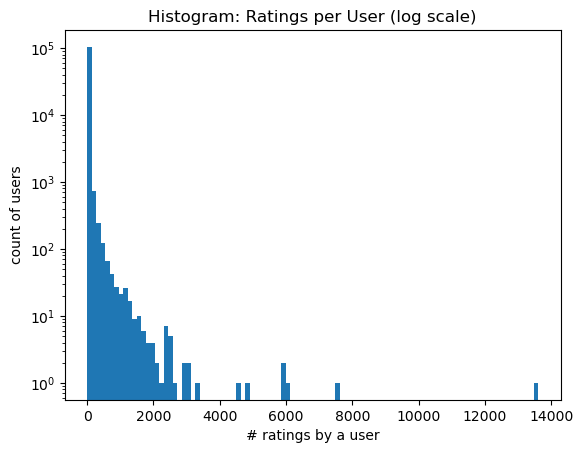

In [251]:
# Users
plt.figure()
plt.hist(cnt_per_user.values, bins=100, log=True)
plt.title('Histogram: Ratings per User (log scale)')
plt.xlabel('# ratings by a user')
plt.ylabel('count of users')
plt.show()

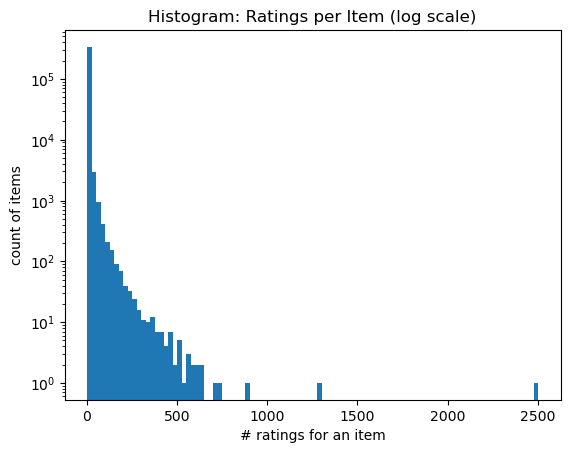

In [247]:
# Items
plt.figure()
plt.hist(cnt_per_item.values, bins=100, log=True)
plt.title('Histogram: Ratings per Item (log scale)')
plt.xlabel('# ratings for an item')
plt.ylabel('count of items')
plt.show()

In [257]:
def choose_k_for_target(ratings, target_frac=0.90, k_max=50, verbose=True):
    """
    Returns: best_k, filtered_df
    - best_k is the largest k in [1..k_max] where retained_ratings / total_ratings ≥ target_frac.
    """
    total = len(ratings)
    best_k = 0
    best_df = ratings

    rows = []
    for k in range(1, k_max+1):
        cur = kcore_filter(ratings, min_u=k, min_i=k)
        frac = len(cur) / total if total > 0 else 0.0
        rows.append((k, len(cur), frac))
        if frac >= target_frac:
            best_k = k
            best_df = cur

    if verbose:
        ret = pd.DataFrame(rows, columns=['k', 'ratings_retained', 'fraction'])
        print("Retention by k (first/last few rows):")
        display(pd.concat([ret.head(5), ret.tail(5)]))
        print(f"\nChosen k = {best_k} (target_frac={target_frac}; total={total}, kept={len(best_df)} ~ {len(best_df)/total:.3f})")

    return best_k, best_df

# Example: aim to keep at least 90% of all ratings
best_k, ratings_k = choose_k_for_target(ratings, target_frac=0.50, k_max=50, verbose=True)
print("After k-core:", ratings_k['user'].nunique(), "users,", ratings_k['item'].nunique(), "items,", len(ratings_k), "ratings")


Retention by k (first/last few rows):


,k,ratings_retained,fraction
0,1,1149780,1.000000
1,2,890826,0.774780
2,3,749983,0.652284
3,4,656228,0.570742
4,5,585579,0.509297
45,46,0,0.000000
46,47,0,0.000000
47,48,0,0.000000
48,49,0,0.000000
49,50,0,0.000000



Chosen k = 5 (target_frac=0.5; total=1149780, kept=585579 ~ 0.509)
After k-core: 15798 users, 38093 items, 585579 ratings


In [233]:
def kcore_filter(df, min_u=5, min_i=5):
    prev_shape = None
    cur = df.copy()
    while True:
        if prev_shape == cur.shape:
            break  # nothing more to remove; we're stable
        prev_shape = cur.shape

        # 1) keep users with at least min_u ratings
        user_counts = cur.groupby('user').size()
        keep_users = user_counts[user_counts >= min_u].index
        cur = cur[cur['user'].isin(keep_users)]

        # 2) keep items with at least min_i ratings
        item_counts = cur.groupby('item').size()
        keep_items = item_counts[item_counts >= min_i].index
        cur = cur[cur['item'].isin(keep_items)]

    return cur


In [235]:
print("Before k-core:", ratings['user'].nunique(), "users,", 
      ratings['item'].nunique(), "items,", len(ratings), "ratings")

Before k-core: 105283 users, 340556 items, 1149780 ratings


In [237]:
ratings_k = kcore_filter(ratings, MIN_USER_INTERACTIONS, MIN_ITEM_INTERACTIONS)
print("After k-core:", ratings_k['user'].nunique(), "users,",
      ratings_k['item'].nunique(), "items,", len(ratings_k), "ratings")


After k-core: 26800 users, 76951 items, 749983 ratings


In [239]:
ratings_k

,user,item,rating
10,276746,0425115801,1
11,276746,0449006522,1
12,276746,0553561618,1
13,276746,055356451X,1
14,276746,0786013990,1
...,...,...,...
1149769,276704,059032120X,1
1149771,276704,0743211383,7
1149772,276704,080410526X,1
1149774,276704,0876044011,1


---